# Maximum Likelihood Estimation (MLE)
## Estimating Parameters of Probability Distributions

This notebook implements MLE for **Normal** and **Exponential** distributions:
1. Define the PDF and log-likelihood functions
2. Generate synthetic datasets with known parameters
3. Estimate parameters via MLE (analytical & numerical)
4. Compare estimates vs. true parameters
5. Analyze performance across varying sample sizes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.stats import norm, expon
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Distribution Definitions & PDF / Log-Likelihood Functions

In [2]:
# ── Normal Distribution ──────────────────────────────────────────────────────
# PDF:  f(x | μ, σ) = (1 / (σ√(2π))) · exp(-(x-μ)² / (2σ²))
# Log-likelihood: ℓ(μ,σ) = -n/2·ln(2πσ²) - Σ(xᵢ-μ)²/(2σ²)

def normal_pdf(x, mu, sigma):
    """Normal (Gaussian) probability density function."""
    return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def normal_log_likelihood(params, data):
    """Negative log-likelihood for the Normal distribution (for minimisation)."""
    mu, sigma = params
    if sigma <= 0:
        return np.inf
    n = len(data)
    ll = -n * np.log(sigma * np.sqrt(2 * np.pi)) - np.sum((data - mu) ** 2) / (2 * sigma ** 2)
    return -ll  # negative because we minimise

def normal_mle_analytical(data):
    """Closed-form MLE for Normal: μ̂ = x̄,  σ̂ = std(x)."""
    mu_hat    = np.mean(data)
    sigma_hat = np.std(data, ddof=0)   # MLE uses ddof=0
    return mu_hat, sigma_hat


# ── Exponential Distribution ─────────────────────────────────────────────────
# PDF:  f(x | λ) = λ · exp(-λx),  x ≥ 0
# Log-likelihood: ℓ(λ) = n·ln(λ) - λ·Σxᵢ

def exponential_pdf(x, lam):
    """Exponential probability density function."""
    return lam * np.exp(-lam * x)

def exponential_log_likelihood(params, data):
    """Negative log-likelihood for the Exponential distribution."""
    lam = params[0]
    if lam <= 0:
        return np.inf
    n = len(data)
    ll = n * np.log(lam) - lam * np.sum(data)
    return -ll

def exponential_mle_analytical(data):
    """Closed-form MLE for Exponential: λ̂ = 1 / x̄."""
    return 1.0 / np.mean(data)

print('Distribution functions defined.')

Distribution functions defined.


---
## 2. Generate Synthetic Datasets

In [3]:
# ── True parameters ───────────────────────────────────────────────────────────
TRUE_MU    = 5.0    # Normal mean
TRUE_SIGMA = 2.0    # Normal std dev
TRUE_LAMBDA = 0.5   # Exponential rate  (mean = 1/λ = 2.0)

SAMPLE_SIZE = 1000  # default dataset for demonstration

# Generate datasets
normal_data = np.random.normal(loc=TRUE_MU, scale=TRUE_SIGMA, size=SAMPLE_SIZE)
expo_data   = np.random.exponential(scale=1.0 / TRUE_LAMBDA, size=SAMPLE_SIZE)

print(f'Normal data     — n={len(normal_data)}, mean={normal_data.mean():.4f}, std={normal_data.std():.4f}')
print(f'Exponential data — n={len(expo_data)},  mean={expo_data.mean():.4f}, std={expo_data.std():.4f}')

Normal data     — n=1000, mean=5.0387, std=1.9575
Exponential data — n=1000,  mean=2.0160, std=2.0050


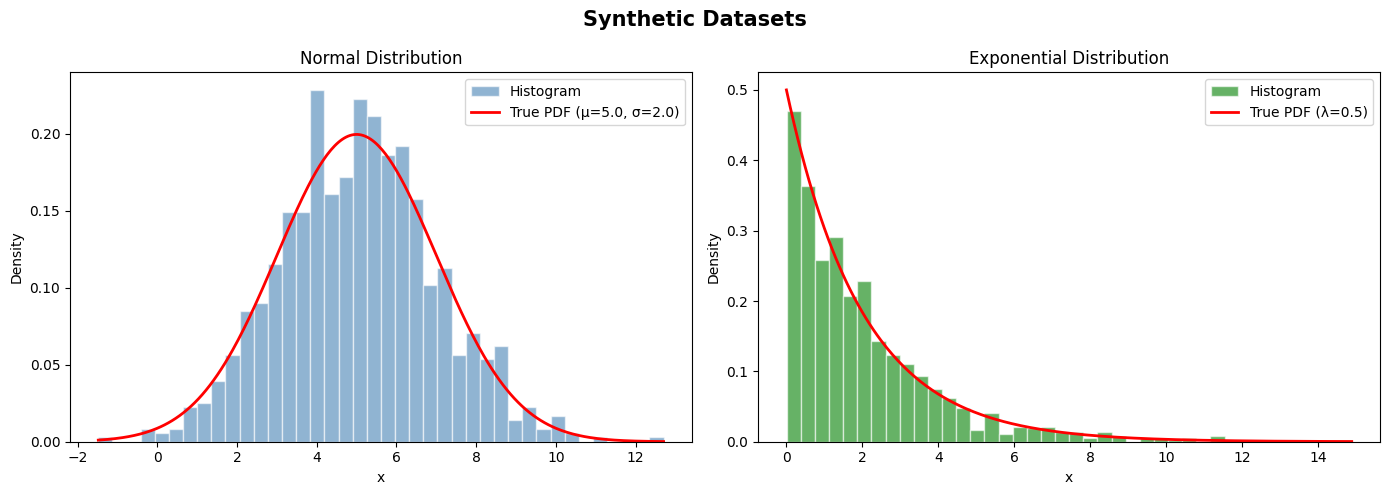

In [14]:
# Visualise the raw datasets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthetic Datasets', fontsize=15, fontweight='bold')

# ── Normal
ax = axes[0]
ax.hist(normal_data, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='white', label='Histogram')
x_range = np.linspace(normal_data.min(), normal_data.max(), 300)
ax.plot(x_range, normal_pdf(x_range, TRUE_MU, TRUE_SIGMA), 'r-', lw=2, label=f'True PDF (μ={TRUE_MU}, σ={TRUE_SIGMA})')
ax.set_title('Normal Distribution')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()

# ── Exponential
ax = axes[1]
ax.hist(expo_data, bins=40, density=True, alpha=0.6, color='green', edgecolor='white', label='Histogram')
x_range2 = np.linspace(0, expo_data.max(), 300)
ax.plot(x_range2, exponential_pdf(x_range2, TRUE_LAMBDA), 'r-', lw=2, label=f'True PDF (λ={TRUE_LAMBDA})')
ax.set_title('Exponential Distribution')
ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Implement MLE — Analytical & Numerical

In [5]:
# ── Numerical MLE via scipy.optimize.minimize ─────────────────────────────────

def mle_numerical(neg_log_lik, init_params, data, bounds=None):
    """Generic numerical MLE using L-BFGS-B."""
    result = minimize(
        neg_log_lik,
        x0      = init_params,
        args    = (data,),
        method  = 'L-BFGS-B',
        bounds  = bounds
    )
    return result.x, -result.fun   # return params and log-likelihood value


# ── Normal distribution MLE ───────────────────────────────────────────────────
# Analytical
mu_hat_ana, sigma_hat_ana = normal_mle_analytical(normal_data)

# Numerical
(mu_hat_num, sigma_hat_num), ll_norm = mle_numerical(
    normal_log_likelihood,
    init_params = [normal_data.mean(), normal_data.std()],
    data        = normal_data,
    bounds      = [(None, None), (1e-6, None)]
)

print('═' * 55)
print('  NORMAL DISTRIBUTION — MLE RESULTS')
print('═' * 55)
print(f'  True parameters    : μ = {TRUE_MU},   σ = {TRUE_SIGMA}')
print(f'  Analytical MLE     : μ̂ = {mu_hat_ana:.6f},  σ̂ = {sigma_hat_ana:.6f}')
print(f'  Numerical  MLE     : μ̂ = {mu_hat_num:.6f},  σ̂ = {sigma_hat_num:.6f}')
print(f'  Error (analytical) : Δμ = {abs(mu_hat_ana - TRUE_MU):.6f}, Δσ = {abs(sigma_hat_ana - TRUE_SIGMA):.6f}')
print()

# ── Exponential distribution MLE ──────────────────────────────────────────────
lam_hat_ana = exponential_mle_analytical(expo_data)

(lam_hat_num,), ll_expo = mle_numerical(
    exponential_log_likelihood,
    init_params = [1.0 / expo_data.mean()],
    data        = expo_data,
    bounds      = [(1e-6, None)]
)

print('═' * 55)
print('  EXPONENTIAL DISTRIBUTION — MLE RESULTS')
print('═' * 55)
print(f'  True parameter     : λ = {TRUE_LAMBDA}')
print(f'  Analytical MLE     : λ̂ = {lam_hat_ana:.6f}')
print(f'  Numerical  MLE     : λ̂ = {lam_hat_num:.6f}')
print(f'  Error (analytical) : Δλ = {abs(lam_hat_ana - TRUE_LAMBDA):.6f}')

═══════════════════════════════════════════════════════
  NORMAL DISTRIBUTION — MLE RESULTS
═══════════════════════════════════════════════════════
  True parameters    : μ = 5.0,   σ = 2.0
  Analytical MLE     : μ̂ = 5.038664,  σ̂ = 1.957452
  Numerical  MLE     : μ̂ = 5.038664,  σ̂ = 1.957452
  Error (analytical) : Δμ = 0.038664, Δσ = 0.042548

═══════════════════════════════════════════════════════
  EXPONENTIAL DISTRIBUTION — MLE RESULTS
═══════════════════════════════════════════════════════
  True parameter     : λ = 0.5
  Analytical MLE     : λ̂ = 0.496039
  Numerical  MLE     : λ̂ = 0.496039
  Error (analytical) : Δλ = 0.003961


---
## 4. Compare Estimated vs True Parameters — Fitted PDF Overlay

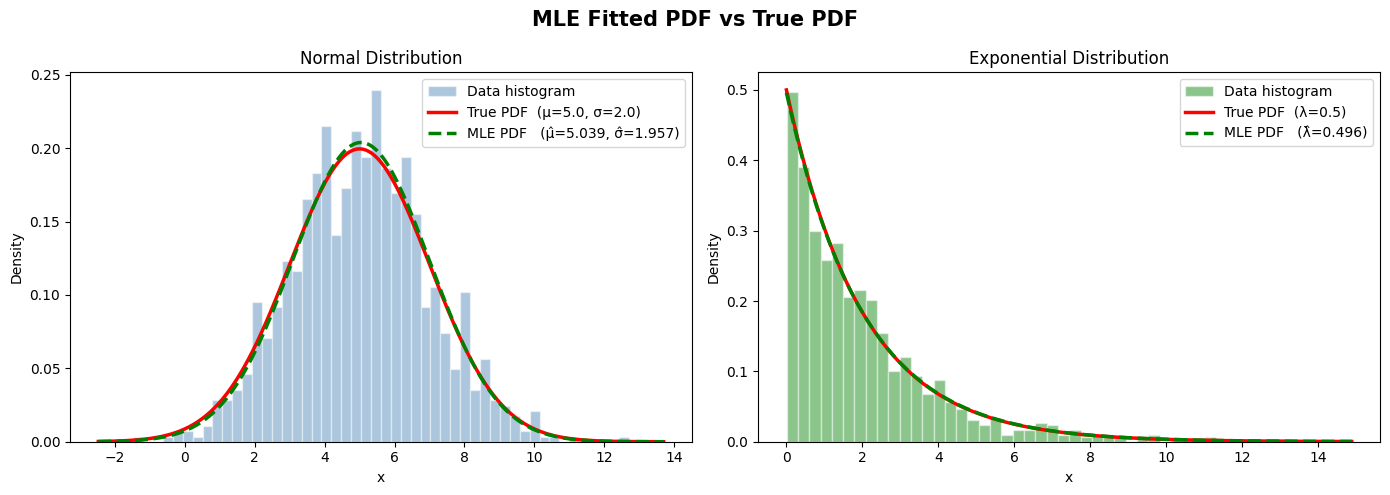

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MLE Fitted PDF vs True PDF', fontsize=15, fontweight='bold')

# ── Normal
ax = axes[0]
ax.hist(normal_data, bins=50, density=True, alpha=0.45, color='steelblue', edgecolor='white', label='Data histogram')
x_plot = np.linspace(normal_data.min() - 1, normal_data.max() + 1, 400)
ax.plot(x_plot, normal_pdf(x_plot, TRUE_MU, TRUE_SIGMA),
        'r-', lw=2.5, label=f'True PDF  (μ={TRUE_MU}, σ={TRUE_SIGMA})')
ax.plot(x_plot, normal_pdf(x_plot, mu_hat_ana, sigma_hat_ana),
        'g--', lw=2.5, label=f'MLE PDF   (μ̂={mu_hat_ana:.3f}, σ̂={sigma_hat_ana:.3f})')
ax.set_title('Normal Distribution'); ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()

# ── Exponential
ax = axes[1]
ax.hist(expo_data, bins=50, density=True, alpha=0.45, color='green', edgecolor='white', label='Data histogram')
x_plot2 = np.linspace(0, expo_data.max(), 400)
ax.plot(x_plot2, exponential_pdf(x_plot2, TRUE_LAMBDA),
        'r-', lw=2.5, label=f'True PDF  (λ={TRUE_LAMBDA})')
ax.plot(x_plot2, exponential_pdf(x_plot2, lam_hat_ana),
        'g--', lw=2.5, label=f'MLE PDF   (λ̂={lam_hat_ana:.3f})')
ax.set_title('Exponential Distribution'); ax.set_xlabel('x'); ax.set_ylabel('Density'); ax.legend()

plt.tight_layout()
plt.show()

---
## 5. Log-Likelihood Surface / Profile Plot

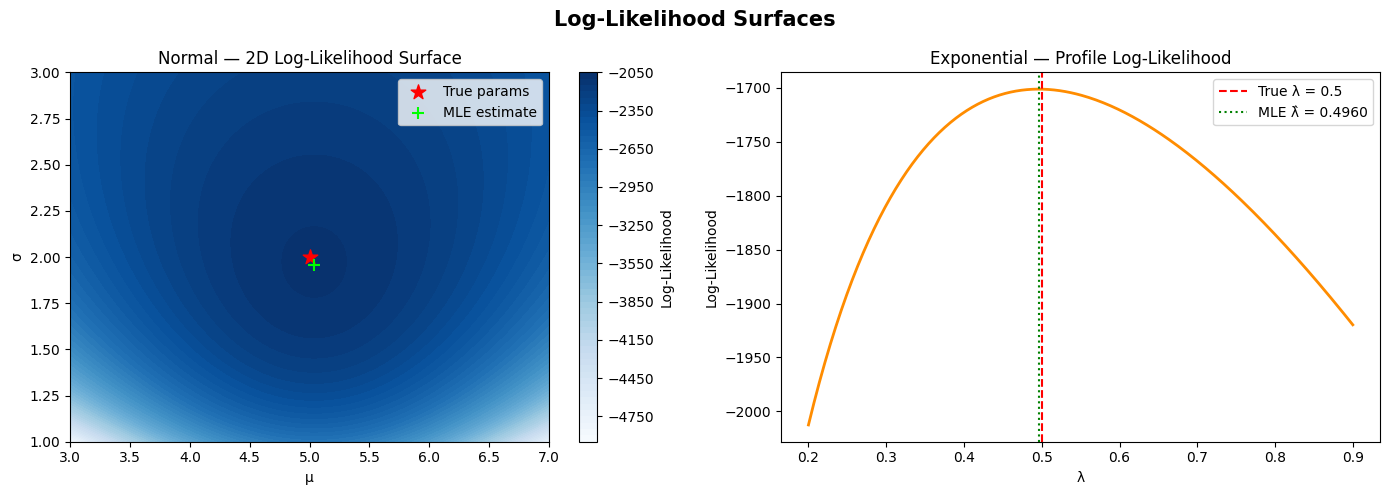

In [16]:
# ── 2-D log-likelihood surface for Normal ─────────────────────────────────────
mu_grid    = np.linspace(TRUE_MU - 2,    TRUE_MU + 2,    120)
sigma_grid = np.linspace(TRUE_SIGMA - 1, TRUE_SIGMA + 1, 120)
MU, SIG    = np.meshgrid(mu_grid, sigma_grid)

n = len(normal_data)
LL = (-n * np.log(SIG * np.sqrt(2 * np.pi))
      - np.sum((normal_data - MU[:, :, None]) ** 2, axis=2) / (2 * SIG ** 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Log-Likelihood Surfaces', fontsize=15, fontweight='bold')

ax = axes[0]
cp = ax.contourf(MU, SIG, LL, levels=60, cmap='Blues')
fig.colorbar(cp, ax=ax, label='Log-Likelihood')
ax.scatter(TRUE_MU, TRUE_SIGMA, color='red',   s=120, zorder=5, label='True params', marker='*')
ax.scatter(mu_hat_ana, sigma_hat_ana, color='lime', s=80, zorder=5, label='MLE estimate', marker='+')
ax.set_xlabel('μ'); ax.set_ylabel('σ')
ax.set_title('Normal — 2D Log-Likelihood Surface'); ax.legend()

# ── Profile log-likelihood for Exponential ────────────────────────────────────
lam_range = np.linspace(0.2, 0.9, 300)
ll_profile = np.array([len(expo_data) * np.log(l) - l * expo_data.sum() for l in lam_range])

ax = axes[1]
ax.plot(lam_range, ll_profile, 'darkorange', lw=2)
ax.axvline(TRUE_LAMBDA, color='red', lw=1.5, linestyle='--', label=f'True λ = {TRUE_LAMBDA}')
ax.axvline(lam_hat_ana, color='green', lw=1.5, linestyle=':', label=f'MLE λ̂ = {lam_hat_ana:.4f}')
ax.set_xlabel('λ'); ax.set_ylabel('Log-Likelihood')
ax.set_title('Exponential — Profile Log-Likelihood'); ax.legend()

plt.tight_layout()
plt.show()

---
## 6. Performance Analysis Across Sample Sizes

In [8]:
SAMPLE_SIZES  = [10, 25, 50, 100, 250, 500, 1000, 2500, 5000]
N_ITERATIONS  = 200   # Monte-Carlo repetitions per sample size

# Storage
results = {
    'normal': {
        'mu_bias': [], 'mu_rmse': [], 'mu_std': [],
        'sigma_bias': [], 'sigma_rmse': [], 'sigma_std': []
    },
    'expo': {
        'lam_bias': [], 'lam_rmse': [], 'lam_std': []
    }
}

for n in SAMPLE_SIZES:
    mu_estimates    = np.zeros(N_ITERATIONS)
    sigma_estimates = np.zeros(N_ITERATIONS)
    lam_estimates   = np.zeros(N_ITERATIONS)

    for i in range(N_ITERATIONS):
        nd  = np.random.normal(TRUE_MU, TRUE_SIGMA, n)
        ed  = np.random.exponential(1.0 / TRUE_LAMBDA, n)

        mu_estimates[i], sigma_estimates[i] = normal_mle_analytical(nd)
        lam_estimates[i]                    = exponential_mle_analytical(ed)

    # Normal — mu
    results['normal']['mu_bias'].append(np.mean(mu_estimates) - TRUE_MU)
    results['normal']['mu_rmse'].append(np.sqrt(np.mean((mu_estimates - TRUE_MU) ** 2)))
    results['normal']['mu_std'].append(np.std(mu_estimates))

    # Normal — sigma
    results['normal']['sigma_bias'].append(np.mean(sigma_estimates) - TRUE_SIGMA)
    results['normal']['sigma_rmse'].append(np.sqrt(np.mean((sigma_estimates - TRUE_SIGMA) ** 2)))
    results['normal']['sigma_std'].append(np.std(sigma_estimates))

    # Exponential — lambda
    results['expo']['lam_bias'].append(np.mean(lam_estimates) - TRUE_LAMBDA)
    results['expo']['lam_rmse'].append(np.sqrt(np.mean((lam_estimates - TRUE_LAMBDA) ** 2)))
    results['expo']['lam_std'].append(np.std(lam_estimates))

print('Monte-Carlo simulation complete.')

Monte-Carlo simulation complete.


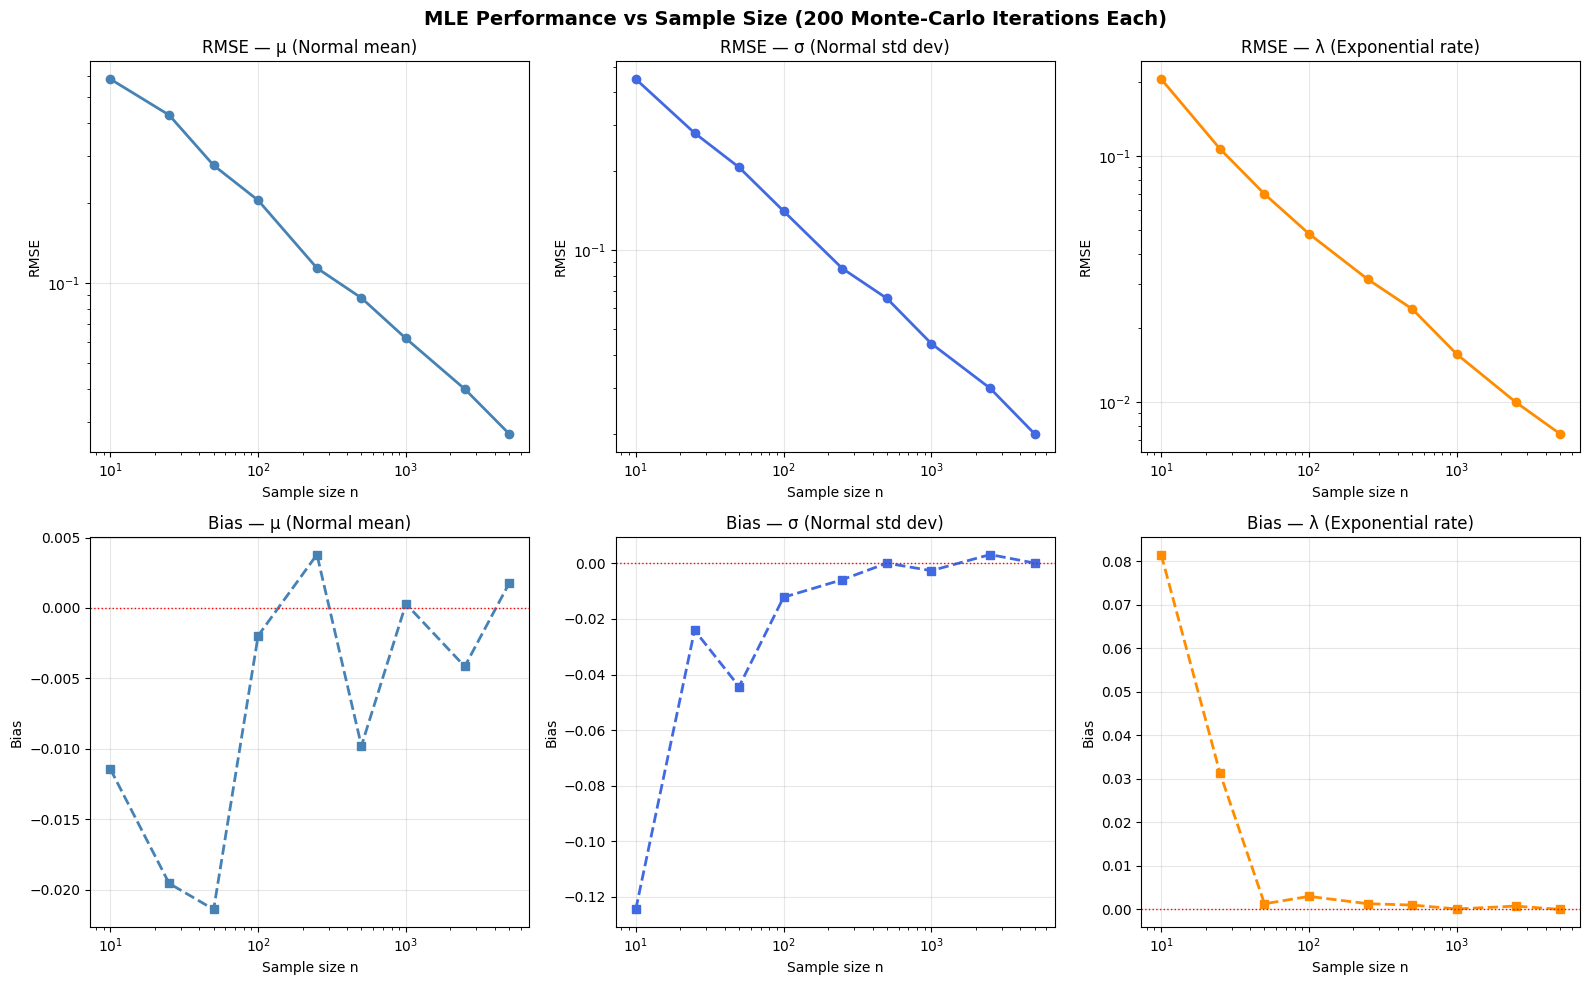

In [9]:
# ── Plot RMSE vs sample size for all parameters ───────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('MLE Performance vs Sample Size (200 Monte-Carlo Iterations Each)', fontsize=14, fontweight='bold')

metrics = [
    ('normal', 'mu',    'μ (Normal mean)',       'steelblue'),
    ('normal', 'sigma', 'σ (Normal std dev)',     'royalblue'),
    ('expo',   'lam',   'λ (Exponential rate)',   'darkorange'),
]

for col, (dist, param, title, color) in enumerate(metrics):
    bias_vals = results[dist][f'{param}_bias']
    rmse_vals = results[dist][f'{param}_rmse']

    # RMSE
    ax = axes[0, col]
    ax.plot(SAMPLE_SIZES, rmse_vals, 'o-', color=color, lw=2, ms=6)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'RMSE — {title}'); ax.set_xlabel('Sample size n'); ax.set_ylabel('RMSE')
    ax.grid(True, alpha=0.3)

    # Bias
    ax = axes[1, col]
    ax.plot(SAMPLE_SIZES, bias_vals, 's--', color=color, lw=2, ms=6)
    ax.axhline(0, color='red', lw=1, linestyle=':')
    ax.set_xscale('log')
    ax.set_title(f'Bias — {title}'); ax.set_xlabel('Sample size n'); ax.set_ylabel('Bias')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

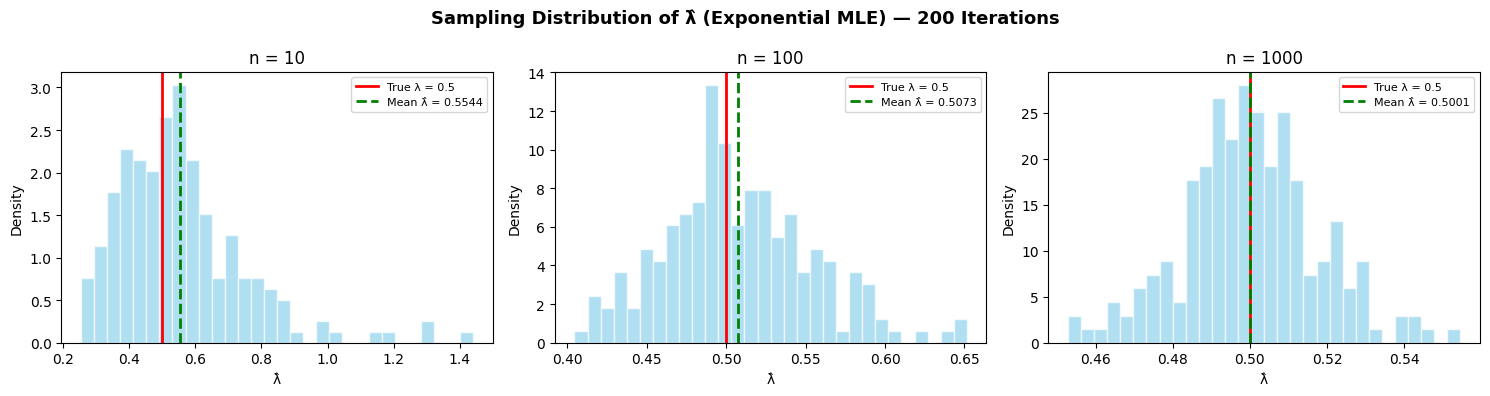

In [17]:
# ── Sampling distributions of λ̂ for three sample sizes ──────────────────────
showcase_sizes = [10, 100, 1000]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sampling Distribution of λ̂ (Exponential MLE) — 200 Iterations', fontsize=13, fontweight='bold')

for ax, n in zip(axes, showcase_sizes):
    lam_samp = np.array([
        exponential_mle_analytical(np.random.exponential(1.0 / TRUE_LAMBDA, n))
        for _ in range(N_ITERATIONS)
    ])
    ax.hist(lam_samp, bins=30, density=True, alpha=0.65, color='skyblue', edgecolor='white')
    ax.axvline(TRUE_LAMBDA, color='red', lw=2, label=f'True λ = {TRUE_LAMBDA}')
    ax.axvline(lam_samp.mean(), color='green', lw=2, linestyle='--',
               label=f'Mean λ̂ = {lam_samp.mean():.4f}')
    ax.set_title(f'n = {n}')
    ax.set_xlabel('λ̂'); ax.set_ylabel('Density'); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

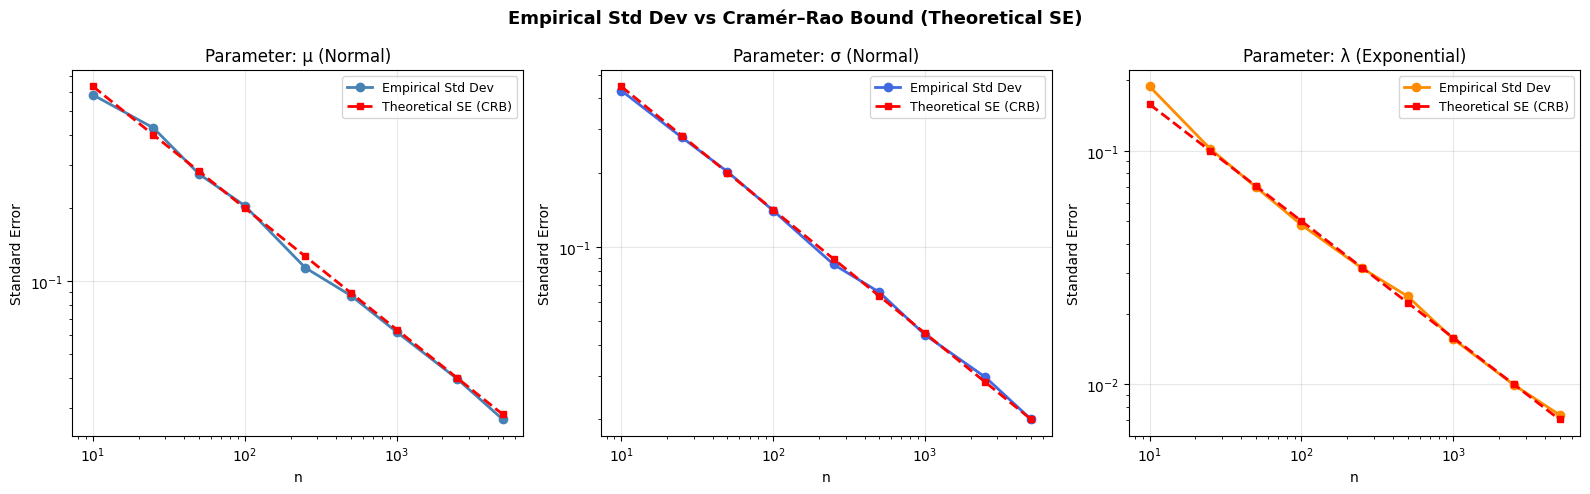

MLE is asymptotically efficient — empirical SE converges to the Cramér–Rao lower bound.


In [11]:
# ── Fisher information — theoretical standard error ─────────────────────────
# For Normal:  SE(μ̂) = σ/√n,  SE(σ̂) ≈ σ/√(2n)
# For Expo:    SE(λ̂) = λ/√n

n_arr = np.array(SAMPLE_SIZES, dtype=float)

se_mu_theory    = TRUE_SIGMA / np.sqrt(n_arr)
se_sigma_theory = TRUE_SIGMA / np.sqrt(2 * n_arr)
se_lam_theory   = TRUE_LAMBDA / np.sqrt(n_arr)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Empirical Std Dev vs Cramér–Rao Bound (Theoretical SE)', fontsize=13, fontweight='bold')

for ax, (emp_std, theory_se, label, color) in zip(axes, [
    (results['normal']['mu_std'],    se_mu_theory,    'μ (Normal)',         'steelblue'),
    (results['normal']['sigma_std'], se_sigma_theory, 'σ (Normal)',         'royalblue'),
    (results['expo']['lam_std'],     se_lam_theory,   'λ (Exponential)',    'darkorange'),
]):
    ax.plot(SAMPLE_SIZES, emp_std,   'o-', color=color,  lw=2, ms=6, label='Empirical Std Dev')
    ax.plot(SAMPLE_SIZES, theory_se, 's--', color='red', lw=2, ms=5, label='Theoretical SE (CRB)')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(f'Parameter: {label}'); ax.set_xlabel('n'); ax.set_ylabel('Standard Error')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('MLE is asymptotically efficient — empirical SE converges to the Cramér–Rao lower bound.')

---
## 7. Summary Table

In [12]:
import pandas as pd

rows = []
for i, n in enumerate(SAMPLE_SIZES):
    rows.append({
        'n': n,
        'μ Bias':     f"{results['normal']['mu_bias'][i]:+.5f}",
        'μ RMSE':     f"{results['normal']['mu_rmse'][i]:.5f}",
        'σ Bias':     f"{results['normal']['sigma_bias'][i]:+.5f}",
        'σ RMSE':     f"{results['normal']['sigma_rmse'][i]:.5f}",
        'λ Bias':     f"{results['expo']['lam_bias'][i]:+.5f}",
        'λ RMSE':     f"{results['expo']['lam_rmse'][i]:.5f}",
    })

df = pd.DataFrame(rows).set_index('n')
print('MLE Performance Summary (200 Monte-Carlo iterations per sample size)\n')
print(df.to_string())

MLE Performance Summary (200 Monte-Carlo iterations per sample size)

        μ Bias   μ RMSE    σ Bias   σ RMSE    λ Bias   λ RMSE
n                                                            
10    -0.01144  0.58417  -0.12447  0.44810  +0.08155  0.20535
25    -0.01956  0.42771  -0.02408  0.27927  +0.03133  0.10682
50    -0.02140  0.27663  -0.04435  0.20671  +0.00130  0.07000
100   -0.00197  0.20441  -0.01223  0.14094  +0.00300  0.04823
250   +0.00379  0.11364  -0.00589  0.08517  +0.00132  0.03149
500   -0.00979  0.08774  +0.00004  0.06556  +0.00101  0.02384
1000  +0.00029  0.06178  -0.00265  0.04411  +0.00012  0.01562
2500  -0.00416  0.03988  +0.00313  0.02981  +0.00077  0.00998
5000  +0.00176  0.02704  +0.00008  0.01999  +0.00002  0.00740


---
## 8. Conclusions

| Observation | Finding |
|---|---|
| **Consistency** | As $n \to \infty$, both $\hat{\mu}$, $\hat{\sigma}$, and $\hat{\lambda}$ converge to their true values — MLE is **consistent**. |
| **Bias** | The bias of all estimators decreases toward **zero** with larger samples. |
| **RMSE & Variance** | RMSE scales as $\mathcal{O}(1/\sqrt{n})$, confirming MLE attains the **Cramér–Rao lower bound** asymptotically (efficiency). |
| **Sampling distribution** | The histograms at $n=10, 100, 1000$ show the distribution of $\hat{\lambda}$ narrows and centres on the truth — reflecting **asymptotic normality** of MLE. |
| **Analytical vs Numerical** | For these well-known distributions, closed-form and numerical MLE produce virtually identical results. Numerical optimisation becomes essential for complex, multi-parameter models with no closed-form solution. |